# Beat tracking

The goal of the code is to change a song genre by adding a simple kick on the beats (mid-level audio feature).

In [2]:
# Import libraries
import numpy as np
import os
import librosa
from librosa import  load
import soundfile as sf
import matplotlib.pyplot as plt

In [6]:
# Audio files directory
DATA_DIR = "../data" 

# Define filenames for audio files from "data"
filename_in = os.path.join(DATA_DIR, "tire_swings.wav")
filename_kick = os.path.join(DATA_DIR, "kick.wav")
filename_out = os.path.join(DATA_DIR, "tire_disco.wav")

## 1. Load a song

In [7]:
SR = 16000
y, sr = load(filename_in, sr = SR)

## 2. Compute the beats

In [8]:
def compute_beats(y, sr):
    """This function uses librosa library to compute beats from an audio signal
    and returns the time index where the beats occur 

    # Parameters
    
    ----------
    y : np.ndarray
        time-domain audio signal
    sr : int, float
        samplerate

    Returns
    -------
    np.ndarray
        sample index where beat occurs
    """

    [tempo, beats] = librosa.beat.beat_track(y = y, sr = sr, units = 'samples')
    return beats

In [9]:
beats = compute_beats(y, sr = SR)

### CHECK: See if the beats are correct

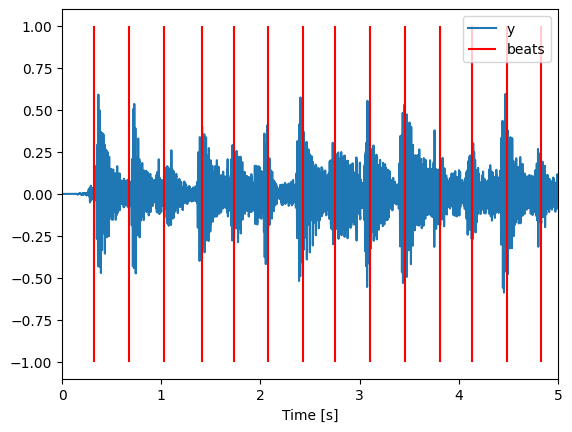

In [10]:
t = np.arange(y.size)/SR    # time axis
plt.figure()
plt.plot(t, y, label = "y")
plt.vlines(t[beats], -1, 1, label = "beats", color = "red")
plt.xlim([0, 5])
plt.xlabel("Time [s]")
plt.legend()
plt.show()

## 3. Load a heavy kick

In [11]:
kick, sr = load(filename_kick, sr = SR)

## 4. Put the kick on the song at the correct beats

In [12]:
def add_samples(y, sample, beats):
    """Add a sample to an audio signal at given beats 

    Parameters
    ----------
    y : np.ndarray
        the original signal
    sample : np.ndarray
        the sample beat to add
    beats : np.ndarray
        the time beats

    Returns
    -------
    np.ndarray
        original signal + sample on beats
    """

    s = np.zeros(y.shape)   # signal with copied kicks
    kick_len = sample.size

    for b in beats:
        s[b : b + kick_len] = sample  # or +=, but kicks may overlap
 
    return y + s

In [13]:
y_out = add_samples(y, kick, beats)

### Show the differences

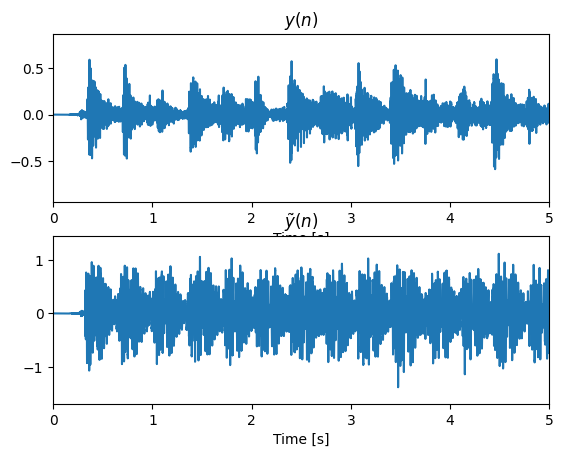

In [14]:
plt.figure()
plt.subplot(2,1,1)
plt.plot(t, y)
plt.xlim([0, 5])
plt.xlabel("Time [s]")
plt.title("$y(n)$")
plt.subplot(2,1,2)
plt.plot(t, y_out)
plt.title("$\\tilde{y}(n)$")
plt.xlim([0, 5])
plt.xlabel("Time [s]")
plt.show()

## 5. Write the final song in a file

In [15]:
sf.write(filename_out, y_out, SR)